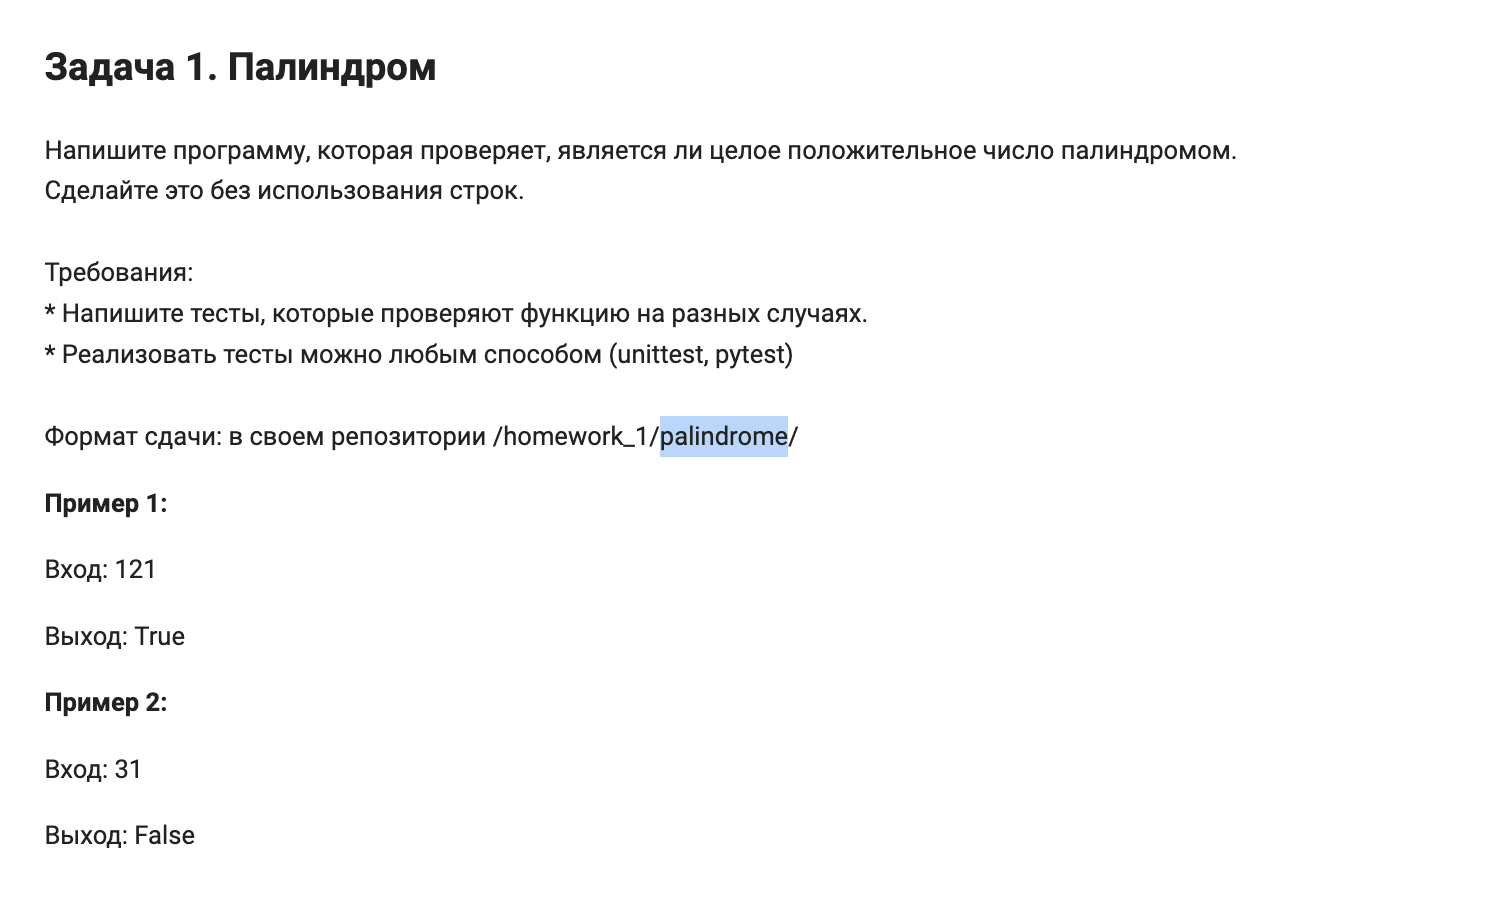

## Ход решения

Поскольку нам нельзя пользоваться строками, будем уменьшать исходное число, убирая первую и последнюю цифру.

Возьмем начальное число и найдем разряд первой цифры. Для этого воспользуемся десятичным логарифмом, поскольку log10(n) показывает порядок числа, а `int(math.log10(n))` дает степень десятки, соответствующую первой цифре.

Далее реализуем следующий алгоритм.

Пока в числе остаются цифры, сравниваем первую и последнюю цифру числа. Первую цифру выделяем как `n // 10 ** power`, а последнюю это будет остаток от деления на 10: `n % 10`.

Если они не равны, сразу прерываем алгоритм и возвращаем False, поскольку число точно не является палиндромом.

В противном случае мы убираем у числа первую и последнюю цифру. Для этого считаем `n % 10 ** power`, таким образом убираем первую цифру, а затем делим результат нацело на 10, так мы уже убираем последнюю цифру.

После этого уменьшаем power на 2, так как мы удалMили сразу две цифры, и повторяем алгоритм.

Если все пары цифр совпали,то есть мы дошли до конца, то есть возвращаем True.

## Сложность алгоритма

- В лучшем случае алгоритм остановится на первом шаге, если первая и последняя цифры не совпадут. Тогда сложность будет `Ω(1)`.

- В худшем случае, если число является палиндромом, мы проверим примерно `n // 2` пар цифр, где `n` — количество цифр в числе. Поэтому временная сложность равна `O(n)`.

- Дополнительная память не используется, поэтому сложность по памяти равна `O(1)`.

# Реализация алгоритма

In [ ]:
import math


def is_palindrome(n):
    power = int(math.log10(n))

    while power >= 0:
        if n // (10 ** power) != n % 10:
            return False

        n = (n % (10 ** power)) // 10
        power -= 2

    return True


# Визуализация работы алгоритма

Рассмотрим работу алгоритма на числе `121232121`.

Изначально `n = 121232121`, `power = 8`.

| Шаг | `n` | `power` | Первая цифра | Последняя цифра | Результат |
| --- | ---: | ---: | ---: | ---: | --- |
| 1 | 121232121 | 8 | 1 | 1 | Совпадают |
| 2 | 2123212 | 6 | 2 | 2 | Совпадают |
| 3 | 12321 | 4 | 1 | 1 | Совпадают |
| 4 | 232 | 2 | 2 | 2 | Совпадают |
| 5 | 3 | 0 | 3 | 3 | Совпадают |

После каждого шага первая и последняя цифры удаляются:

`121232121 → 2123212 → 12321 → 232 → 3`

Все пары цифр совпали, поэтому число `121232121` является палиндромом.


# Тесты

По условию на вход подается целое положительное число, поэтому **0** и отрицательные числа отдельно не проверяем.

Проверим примеры из условия, однозначное число, палиндромы с четным и нечетным количеством цифр, числа с нулями внутри и несколько чисел, которые не являются палиндромами.


In [ ]:
import unittest


class TestPalindrome(unittest.TestCase):
    def test_examples(self):
        self.assertTrue(is_palindrome(121))
        self.assertFalse(is_palindrome(31))

    def test_palindromes(self):
        self.assertTrue(is_palindrome(1))
        self.assertTrue(is_palindrome(1221))
        self.assertTrue(is_palindrome(121232121))

    def test_zeros_inside(self):
        self.assertTrue(is_palindrome(1001))
        self.assertTrue(is_palindrome(10101))

    def test_not_palindromes(self):
        self.assertFalse(is_palindrome(10))
        self.assertFalse(is_palindrome(12345))


_ = unittest.main(argv=[""], exit=False)


....
----------------------------------------------------------------------
Ran 4 tests in 0.003s

OK


# Проверка на нетривиальном примере

In [ ]:
print(is_palindrome(121232121))


True
